In [4]:
import findspark
findspark.init()

## Create a spark session

In [5]:
from pyspark.sql import SparkSession

spark = SparkSession.builder. \
    appName("NYCJobsChallenge"). \
    getOrCreate()
	

## Read the raw file into a dataframe

In [8]:
df = spark.read.csv("/dataset/nyc-jobs.csv", header=True)
df.printSchema()
df.show(5)

root
 |-- Job ID: string (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting Type: string (nullable = true)
 |-- # Of Positions: string (nullable = true)
 |-- Business Title: string (nullable = true)
 |-- Civil Service Title: string (nullable = true)
 |-- Title Code No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job Category: string (nullable = true)
 |-- Full-Time/Part-Time indicator: string (nullable = true)
 |-- Salary Range From: string (nullable = true)
 |-- Salary Range To: string (nullable = true)
 |-- Salary Frequency: string (nullable = true)
 |-- Work Location: string (nullable = true)
 |-- Division/Work Unit: string (nullable = true)
 |-- Job Description: string (nullable = true)
 |-- Minimum Qual Requirements: string (nullable = true)
 |-- Preferred Skills: string (nullable = true)
 |-- Additional Information: string (nullable = true)
 |-- To Apply: string (nullable = true)
 |-- Hours/Shift: string (nullable = true)
 |-- Work Locatio

## ####Data profiling####
###Data Profiling : - identify column types - 
##Count missing values - 
##Check distinct values for categorical columns - 
##Compute basic statistics for numerical columns

In [17]:
import pyspark.sql.functions as F

# Print schema
df.printSchema()

# Total rows
print("Total rows:", df.count())

# Missing values per column (explicit loop)
for c in df.columns:
    missing = df.filter(F.col(c).isNull() | F.isnan(F.col(c)) | (F.col(c) == "")).count()
    print(f"Column: {c}, Missing values: {missing}")

# Distinct values for categorical columns
categorical_cols = ["Agency", "Job Category", "Salary Frequency", "Full-Time/Part-Time indicator"]
for col_name in categorical_cols:
    print(f"\nDistinct values in {col_name}:")
    df.select(col_name).distinct().show(truncate=False)

# Summary statistics for numerical columns
numeric_cols = ["Salary Range From", "Salary Range To", "# Of Positions"]
for col_name in numeric_cols:
    print(f"\nSummary stats for {col_name}:")
    df.select(F.col(col_name)).describe().show()


root
 |-- Job ID: string (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting Type: string (nullable = true)
 |-- # Of Positions: string (nullable = true)
 |-- Business Title: string (nullable = true)
 |-- Civil Service Title: string (nullable = true)
 |-- Title Code No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job Category: string (nullable = true)
 |-- Full-Time/Part-Time indicator: string (nullable = true)
 |-- Salary Range From: string (nullable = true)
 |-- Salary Range To: string (nullable = true)
 |-- Salary Frequency: string (nullable = true)
 |-- Work Location: string (nullable = true)
 |-- Division/Work Unit: string (nullable = true)
 |-- Job Description: string (nullable = true)
 |-- Minimum Qual Requirements: string (nullable = true)
 |-- Preferred Skills: string (nullable = true)
 |-- Additional Information: string (nullable = true)
 |-- To Apply: string (nullable = true)
 |-- Hours/Shift: string (nullable = true)
 |-- Work Locatio

+----------------+
|Salary Frequency|
+----------------+
|Annual          |
|Daily           |
|Hourly          |
+----------------+


Distinct values in Full-Time/Part-Time indicator:
+-----------------------------+
|Full-Time/Part-Time indicator|
+-----------------------------+
|F                            |
|null                         |
|P                            |
+-----------------------------+


Summary stats for Salary Range From:
+-------+------------------+
|summary| Salary Range From|
+-------+------------------+
|  count|              2946|
|   mean|58904.139793856084|
| stddev|26986.575935791352|
|    min|                 0|
|    max|             99353|
+-------+------------------+


Summary stats for Salary Range To:
+-------+-----------------+
|summary|  Salary Range To|
+-------+-----------------+
|  count|             2946|
|   mean|85535.71162739307|
| stddev|42871.31345366744|
|    min|            10.36|
|    max|            99406|
+-------+-----------------+




### Data Cleaning with custom functions 

In [18]:
import pyspark.sql.functions as F
from pyspark.sql.types import DoubleType, IntegerType

def clean_numeric_columns(df):
    """
    Cast numeric columns to appropriate types.
    """
    return df.withColumn("Salary Range From", F.col("Salary Range From").cast(DoubleType())) \
             .withColumn("Salary Range To", F.col("Salary Range To").cast(DoubleType())) \
             .withColumn("# Of Positions", F.col("# Of Positions").cast(IntegerType()))

def clean_date_columns(df):
    """
    Convert date columns to DateType.
    """
    return df.withColumn("Posting Date", F.to_date(F.col("Posting Date"), "yyyy-MM-dd")) \
             .withColumn("Process Date", F.to_date(F.col("Process Date"), "yyyy-MM-dd")) \
             .withColumn("Posting Updated", F.to_date(F.col("Posting Updated"), "yyyy-MM-dd"))

def handle_nulls(df):
    """
    Drop rows with missing salary values.
    """
    return df.filter(F.col("Salary Range From").isNotNull() & F.col("Salary Range To").isNotNull())

def normalize_categorical(df):
    """
    Trim and standardize categorical columns.
    """
    return df.withColumn("Salary Frequency", F.upper(F.trim(F.col("Salary Frequency")))) \
             .withColumn("Full-Time/Part-Time indicator", F.upper(F.trim(F.col("Full-Time/Part-Time indicator")))) \
             .withColumn("Agency", F.trim(F.col("Agency"))) \
             .withColumn("Job Category", F.trim(F.col("Job Category")))


## Applying feature engineering 

In [19]:
def add_salary_midpoint(df):
    """
    Add a new column for salary midpoint.
    """
    return df.withColumn("Salary Midpoint", 
                         (F.col("Salary Range From") + F.col("Salary Range To")) / 2)

def add_posting_age(df):
    """
    Add a new column for posting age in days.
    """
    return df.withColumn("Posting Age", 
                         F.datediff(F.current_date(), F.col("Posting Date")))

def encode_degree(df):
    """
    Encode degree requirements into numeric values.
    Example: Bachelor's=1, Master's=2, PhD=3
    """
    return df.withColumn("DegreeRequirement", 
                         F.when(F.col("Minimum Qual Requirements").rlike("Bachelor"), 1)
                          .when(F.col("Minimum Qual Requirements").rlike("Master"), 2)
                          .when(F.col("Minimum Qual Requirements").rlike("PhD"), 3)
                          .otherwise(0))



## Call the clean and feature engineering functions 

In [20]:
# Apply cleaning and feature engineering
df_clean = clean_numeric_columns(df)
df_clean = clean_date_columns(df_clean)
df_clean = handle_nulls(df_clean)
df_clean = normalize_categorical(df_clean)

df_clean = add_salary_midpoint(df_clean)
df_clean = add_posting_age(df_clean)
df_clean = encode_degree(df_clean)

# Preview cleaned and enriched data
df_clean.show(5)


+------+--------------------+------------+--------------+--------------------+--------------------+-------------+-----+--------------------+-----------------------------+-----------------+---------------+----------------+--------------------+--------------------+--------------------+-------------------------+--------------------+----------------------+--------------------+--------------------+--------------------+--------------------+---------------------+------------+--------------------+---------------+------------+---------------+-----------+-----------------+
|Job ID|              Agency|Posting Type|# Of Positions|      Business Title| Civil Service Title|Title Code No|Level|        Job Category|Full-Time/Part-Time indicator|Salary Range From|Salary Range To|Salary Frequency|       Work Location|  Division/Work Unit|     Job Description|Minimum Qual Requirements|    Preferred Skills|Additional Information|            To Apply|         Hours/Shift|     Work Location 1| Recruitment 

In [21]:
df_clean.show(5)


+------+--------------------+------------+--------------+--------------------+--------------------+-------------+-----+--------------------+-----------------------------+-----------------+---------------+----------------+--------------------+--------------------+--------------------+-------------------------+--------------------+----------------------+--------------------+--------------------+--------------------+--------------------+---------------------+------------+--------------------+---------------+------------+---------------+-----------+-----------------+
|Job ID|              Agency|Posting Type|# Of Positions|      Business Title| Civil Service Title|Title Code No|Level|        Job Category|Full-Time/Part-Time indicator|Salary Range From|Salary Range To|Salary Frequency|       Work Location|  Division/Work Unit|     Job Description|Minimum Qual Requirements|    Preferred Skills|Additional Information|            To Apply|         Hours/Shift|     Work Location 1| Recruitment 

## Calculate the KPI 

In [22]:
import pyspark.sql.functions as F

def get_top_job_categories(df, n=10):
    """
    KPI 1: Top N job categories by number of postings.
    """
    return df.groupBy("Job Category") \
             .count() \
             .orderBy(F.desc("count")) \
             .limit(n)

def get_salary_distribution(df):
    """
    KPI 2: Salary distribution per job category.
    """
    return df.groupBy("Job Category") \
             .agg(F.min("Salary Range From").alias("Min Salary"),
                  F.max("Salary Range To").alias("Max Salary"),
                  F.avg("Salary Midpoint").alias("Avg Salary")) \
             .orderBy(F.desc("Avg Salary"))

def get_degree_salary_correlation(df):
    """
    KPI 3: Correlation between degree requirement and salary.
    Uses encoded DegreeRequirement column.
    """
    return df.stat.corr("DegreeRequirement", "Salary Midpoint")

def get_highest_salary_per_agency(df):
    """
    KPI 4: Job posting with the highest salary per agency.
    """
    return df.groupBy("Agency") \
             .agg(F.max("Salary Range To").alias("Highest Salary")) \
             .orderBy(F.desc("Highest Salary"))

def get_avg_salary_per_agency_last2yrs(df):
    """
    KPI 5: Average salary per agency for the last 2 years.
    """
    cutoff_date = F.add_months(F.current_date(), -24)
    return df.filter(F.col("Posting Date") >= cutoff_date) \
             .groupBy("Agency") \
             .agg(F.avg("Salary Midpoint").alias("Avg Salary Last 2 Years")) \
             .orderBy(F.desc("Avg Salary Last 2 Years"))

def get_highest_paid_skills(df):
    """
    KPI 6: Highest paid skills in the US market.
    Explodes Preferred Skills column and computes average salary.
    """
    return df.withColumn("Skill", F.explode(F.split(F.col("Preferred Skills"), ","))) \
             .groupBy(F.trim(F.col("Skill")).alias("Skill")) \
             .agg(F.avg("Salary Midpoint").alias("Avg Salary")) \
             .orderBy(F.desc("Avg Salary"))


# Execute KPI functions
top_categories = get_top_job_categories(df_clean)
salary_distribution = get_salary_distribution(df_clean)
degree_corr = get_degree_salary_correlation(df_clean)
highest_salary_agency = get_highest_salary_per_agency(df_clean)
avg_salary_last2yrs = get_avg_salary_per_agency_last2yrs(df_clean)
highest_paid_skills = get_highest_paid_skills(df_clean)

# Show results
print("Top 10 Job Categories:")
top_categories.show()

print("Salary Distribution per Job Category:")
salary_distribution.show()

print("Correlation between Degree Requirement and Salary:")
print(degree_corr)

print("Highest Salary per Agency:")
highest_salary_agency.show()

print("Average Salary per Agency (Last 2 Years):")
avg_salary_last2yrs.show()

print("Highest Paid Skills:")
highest_paid_skills.show(20, truncate=False)


Top 10 Job Categories:
+--------------------+-----+
|        Job Category|count|
+--------------------+-----+
|Engineering, Arch...|  504|
|Technology, Data ...|  313|
|       Legal Affairs|  226|
|Public Safety, In...|  182|
|Building Operatio...|  181|
|Finance, Accounti...|  169|
|Administration & ...|  134|
|Constituent Servi...|  129|
|              Health|  125|
|Policy, Research ...|  124|
+--------------------+-----+

Salary Distribution per Job Category:
+--------------------+----------+----------+------------------+
|        Job Category|Min Salary|Max Salary|        Avg Salary|
+--------------------+----------+----------+------------------+
|Administration & ...|  218587.0|  218587.0|          218587.0|
|Engineering, Arch...|  198518.0|  198518.0|          198518.0|
|Engineering, Arch...|  175000.0|  209585.0|          196042.5|
|Health Policy, Re...|   82008.0|  180000.0|          128694.5|
|Engineering, Arch...|   69940.0|  186555.0|          128247.5|
|Engineering, Arch..

## Plot the KPI's

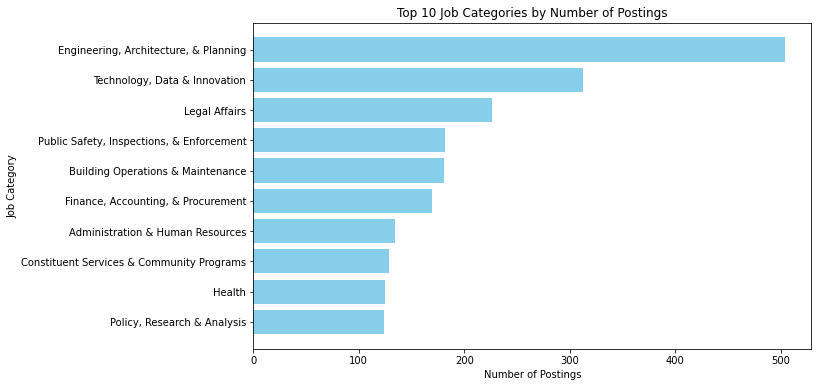

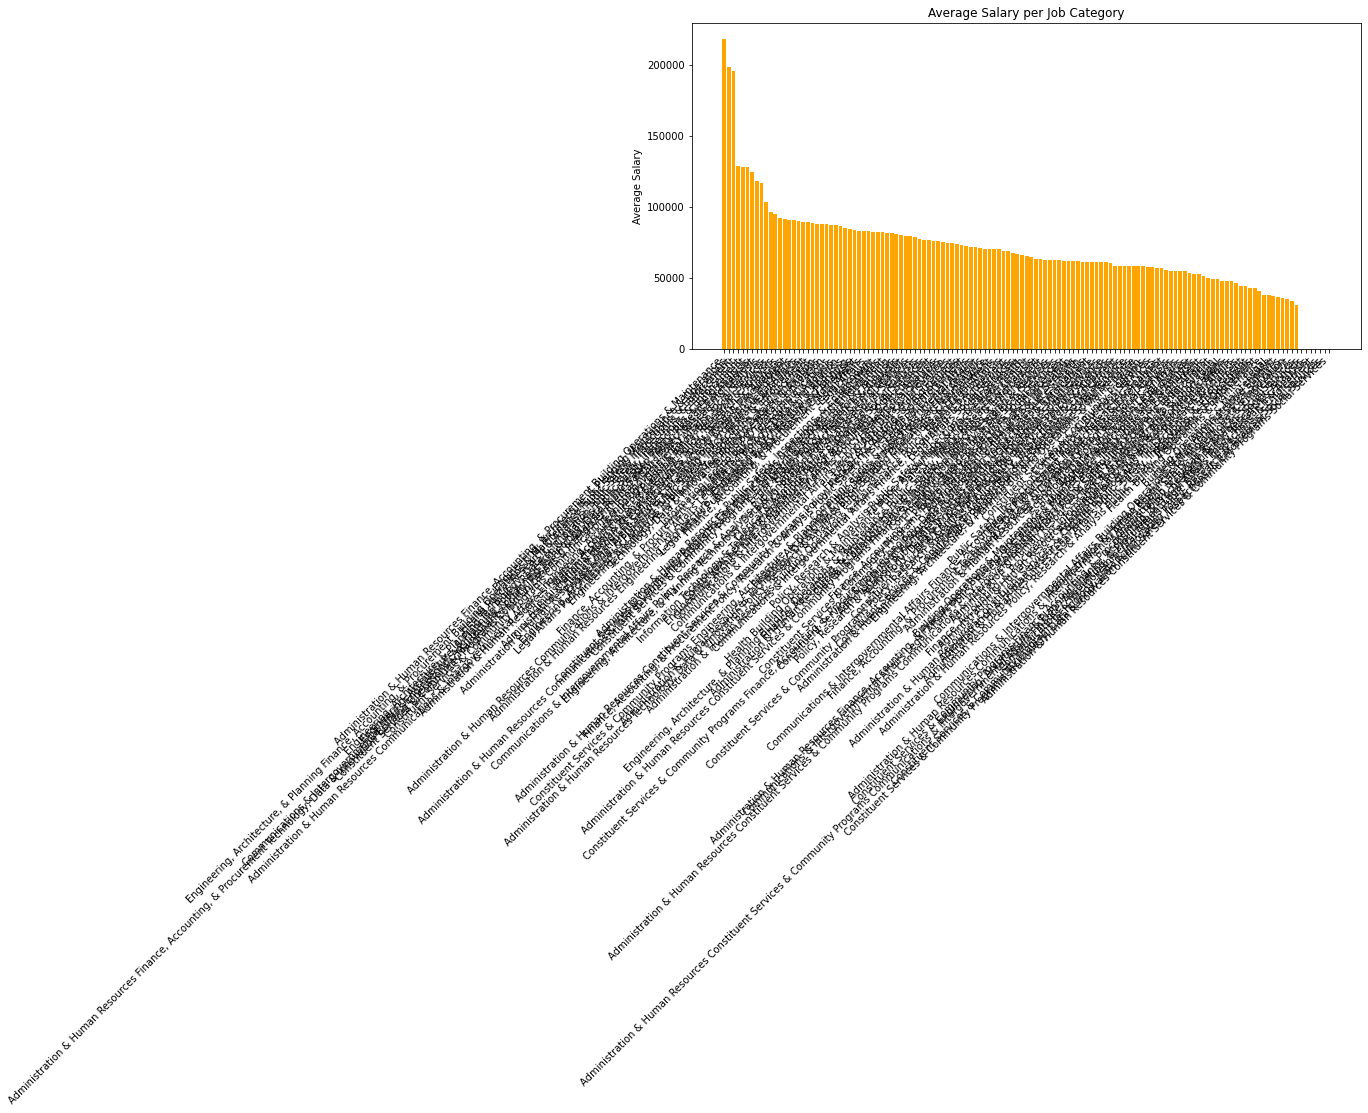

Correlation coefficient: 0.041506706753159164


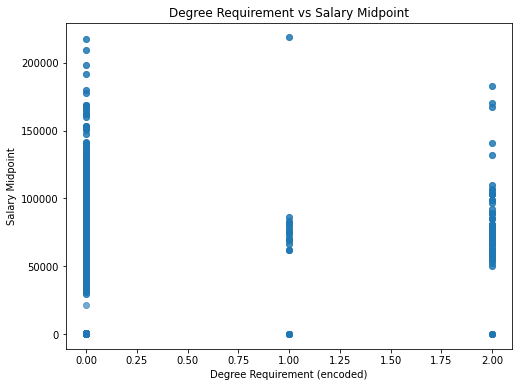

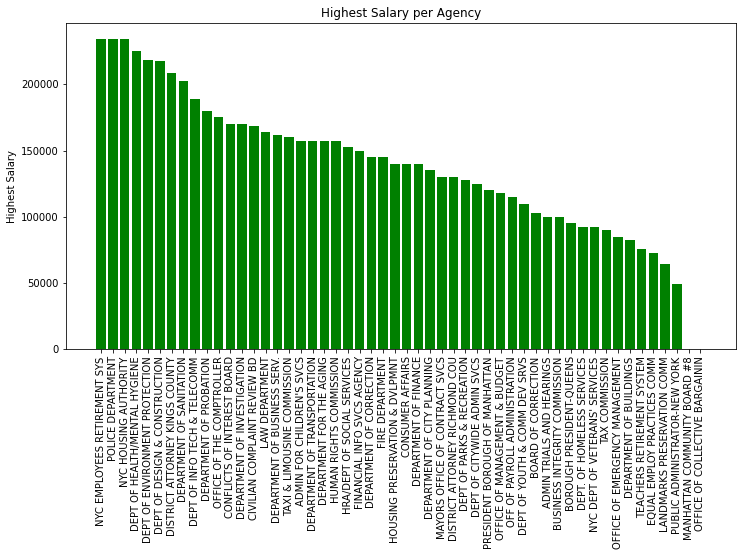

No job postings found in the last 2 years.


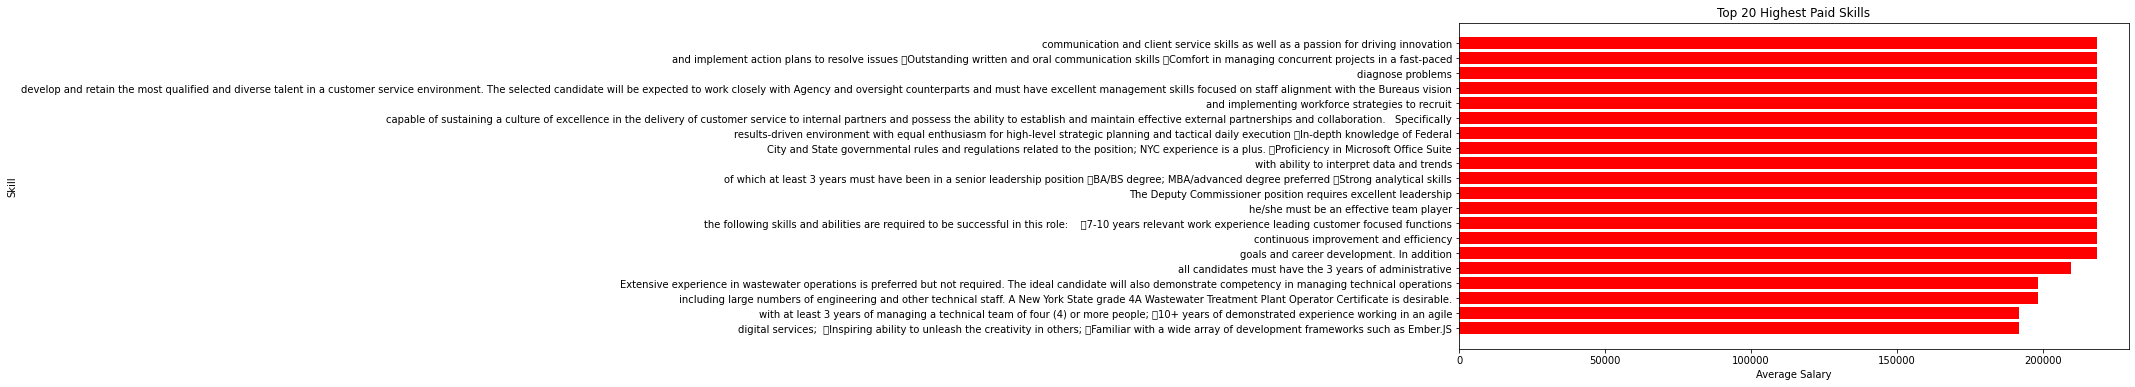

In [26]:
import matplotlib.pyplot as plt

def clean_labels(series):
    """Replace nulls and strip non-ASCII characters from labels."""
    return series.fillna("Unknown").astype(str).str.encode("ascii", "ignore").str.decode("ascii")

# 1. Top 10 Job Categories
top_categories_pd = top_categories.toPandas()
if not top_categories_pd.empty:
    top_categories_pd["Job Category"] = clean_labels(top_categories_pd["Job Category"])
    plt.figure(figsize=(10,6))
    plt.barh(top_categories_pd["Job Category"], top_categories_pd["count"], color="skyblue")
    plt.title("Top 10 Job Categories by Number of Postings")
    plt.xlabel("Number of Postings")
    plt.ylabel("Job Category")
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("No data available for Top Job Categories.")

# 2. Salary Distribution per Job Category
salary_distribution_pd = salary_distribution.toPandas()
if not salary_distribution_pd.empty:
    salary_distribution_pd["Job Category"] = clean_labels(salary_distribution_pd["Job Category"])
    plt.figure(figsize=(12,6))
    plt.bar(salary_distribution_pd["Job Category"], salary_distribution_pd["Avg Salary"], color="orange")
    plt.xticks(rotation=45, ha="right")
    plt.title("Average Salary per Job Category")
    plt.ylabel("Average Salary")
    plt.show()
else:
    print("No data available for Salary Distribution.")

# 3. Correlation between Degree Requirement and Salary
print("Correlation coefficient:", degree_corr)
degree_salary_pd = df_clean.select("DegreeRequirement", "Salary Midpoint").toPandas()
if not degree_salary_pd.empty:
    plt.figure(figsize=(8,6))
    plt.scatter(degree_salary_pd["DegreeRequirement"], degree_salary_pd["Salary Midpoint"], alpha=0.6)
    plt.title("Degree Requirement vs Salary Midpoint")
    plt.xlabel("Degree Requirement (encoded)")
    plt.ylabel("Salary Midpoint")
    plt.show()
else:
    print("No data available for Degree vs Salary plot.")

# 4. Highest Salary per Agency
highest_salary_agency_pd = highest_salary_agency.toPandas()
if not highest_salary_agency_pd.empty:
    highest_salary_agency_pd["Agency"] = clean_labels(highest_salary_agency_pd["Agency"])
    plt.figure(figsize=(12,6))
    plt.bar(highest_salary_agency_pd["Agency"], highest_salary_agency_pd["Highest Salary"], color="green")
    plt.xticks(rotation=90)
    plt.title("Highest Salary per Agency")
    plt.ylabel("Highest Salary")
    plt.show()
else:
    print("No data available for Highest Salary per Agency.")

# 5. Average Salary per Agency (Last 2 Years)
avg_salary_last2yrs_pd = avg_salary_last2yrs.toPandas()
if not avg_salary_last2yrs_pd.empty:
    avg_salary_last2yrs_pd["Agency"] = clean_labels(avg_salary_last2yrs_pd["Agency"])
    plt.figure(figsize=(12,6))
    plt.bar(avg_salary_last2yrs_pd["Agency"], avg_salary_last2yrs_pd["Avg Salary Last 2 Years"], color="purple")
    plt.xticks(rotation=90)
    plt.title("Average Salary per Agency (Last 2 Years)")
    plt.ylabel("Average Salary")
    plt.show()
else:
    print("No job postings found in the last 2 years.")

# 6. Highest Paid Skills
highest_paid_skills_pd = highest_paid_skills.limit(20).toPandas()
if not highest_paid_skills_pd.empty:
    highest_paid_skills_pd["Skill"] = clean_labels(highest_paid_skills_pd["Skill"])
    plt.figure(figsize=(12,6))
    plt.barh(highest_paid_skills_pd["Skill"], highest_paid_skills_pd["Avg Salary"], color="red")
    plt.title("Top 20 Highest Paid Skills")
    plt.xlabel("Average Salary")
    plt.ylabel("Skill")
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("No data available for Highest Paid Skills.")



    
    
    
    
    
    
    
    
    
    
    
    
    
    
    



## Save the dataframe

In [27]:
df_final = df_clean.drop("To Apply", "Recruitment Contact", "Additional Information")


import pyspark.sql.functions as F

# Create a copy of the DataFrame
df_safe = df_final

# Loop through all columns and rename them
for col_name in df_safe.columns:
    safe_name = (
        col_name.replace(" ", "_")
                .replace("#", "Num")
                .replace("/", "_")
                .replace("-", "_")
                .replace("(", "")
                .replace(")", "")
                .replace(".", "")
                .replace("\n", "")
                .replace("\t", "")
                .replace("=", "")
    )
    df_safe = df_safe.withColumnRenamed(col_name, safe_name)

# Now write to Parquet safely
df_safe.write.mode("overwrite").parquet("/dataset/nyc_jobs_processed")

In [ ]:
import pyspark.sql.functions as F
from datetime import date, timedelta

# 1. Test Top Job Categories
def test_get_top_job_categories():
    mock_data = [
        ("Engineering", 1),
        ("Engineering", 2),
        ("Finance", 3),
        ("HR", 4),
        ("Finance", 5)
    ]
    schema = ["Job Category", "id"]
    mock_df = spark.createDataFrame(data=mock_data, schema=schema)
    
    expected_result = {("Engineering", 2), ("Finance", 2), ("HR", 1)}
    result = get_top_job_categories(mock_df, n=3).collect()
    result_tuples = {(row["Job Category"], row["count"]) for row in result}
    
    assert result_tuples == expected_result
    print("test_get_top_job_categories passed.")

# 2. Test Salary Distribution
def test_get_salary_distribution():
    mock_data = [
        ("Engineering", 50000, 70000, 60000),
        ("Engineering", 60000, 80000, 70000),
        ("Finance", 40000, 60000, 50000)
    ]
    schema = ["Job Category", "Salary Range From", "Salary Range To", "Salary Midpoint"]
    mock_df = spark.createDataFrame(data=mock_data, schema=schema)
    
    result = get_salary_distribution(mock_df).collect()
    result_dict = {row["Job Category"]: row["Avg Salary"] for row in result}
    
    assert result_dict["Engineering"] > result_dict["Finance"]
    print("test_get_salary_distribution passed.")

# 3. Test Degree vs Salary Correlation
def test_get_degree_salary_correlation():
    mock_data = [
        (1, 50000),
        (2, 70000),
        (3, 90000)
    ]
    schema = ["DegreeRequirement", "Salary Midpoint"]
    mock_df = spark.createDataFrame(data=mock_data, schema=schema)
    
    corr = get_degree_salary_correlation(mock_df)
    assert corr > 0  # positive correlation expected
    print("test_get_degree_salary_correlation passed.")

# 4. Test Highest Salary per Agency
def test_get_highest_salary_per_agency():
    mock_data = [
        ("AgencyA", 50000, 70000, 60000),
        ("AgencyA", 60000, 80000, 70000),
        ("AgencyB", 40000, 90000, 65000)
    ]
    schema = ["Agency", "Salary Range From", "Salary Range To", "Salary Midpoint"]
    mock_df = spark.createDataFrame(data=mock_data, schema=schema)
    
    result = get_highest_salary_per_agency(mock_df).collect()
    result_dict = {row["Agency"]: row["Highest Salary"] for row in result}
    
    assert result_dict["AgencyB"] == 90000
    print("test_get_highest_salary_per_agency passed.")

# 5. Test Average Salary per Agency (Last 2 Years)
def test_get_avg_salary_per_agency_last2yrs():
    cutoff = date.today() - timedelta(days=600)  # ~2 years
    
    mock_data = [
        ("AgencyA", 50000, cutoff.strftime("%Y-%m-%d")),
        ("AgencyB", 70000, date.today().strftime("%Y-%m-%d"))
    ]
    schema = ["Agency", "Salary Midpoint", "Posting Date"]
    mock_df = spark.createDataFrame(data=mock_data, schema=schema)
    
    result = get_avg_salary_per_agency_last2yrs(mock_df).collect()
    agencies = {row["Agency"] for row in result}
    
    assert "AgencyB" in agencies
    print("test_get_avg_salary_per_agency_last2yrs passed.")

# 6. Test Highest Paid Skills
def test_get_highest_paid_skills():
    mock_data = [
        ("SkillA,SkillB", 70000),
        ("SkillC", 90000)
    ]
    schema = ["Preferred Skills", "Salary Midpoint"]
    mock_df = spark.createDataFrame(data=mock_data, schema=schema)
    
    result = get_highest_paid_skills(mock_df).collect()
    skills = {row["Skill"] for row in result}
    
    assert "SkillC" in skills
    print("test_get_highest_paid_skills passed.")

## Execute the custom test functions 

In [28]:

test_get_top_job_categories()
test_get_salary_distribution()
test_get_degree_salary_correlation()
test_get_highest_salary_per_agency()
test_get_avg_salary_per_agency_last2yrs()
test_get_highest_paid_skills()

test_get_top_job_categories passed.
test_get_salary_distribution passed.
test_get_degree_salary_correlation passed.
test_get_highest_salary_per_agency passed.
test_get_avg_salary_per_agency_last2yrs passed.
test_get_highest_paid_skills passed.
